$
\def\D{\Omega}
\def\ipar{m}
\def\R{\mathbb{R}}
\def\del{\partial}
\def\vec{\bf}
\def\priorm{\mu_0}
\def\C{\mathcal{C}}
\def\Acal{\mathcal{A}}
\def\postm{\mu_{\rm{post}}}
\def\iparpost{\ipar_\text{post}}
\def\obs{ {\vec d}} 
\def\yobs{\obs^{\text{obs}}}
\def\obsop{\mathcal{B}}
\def\dd{\vec{\bar{d}}}
\def\iFF{\mathcal{F}}
\def\iFFadj{\mathcal{F}^*}
\def\ncov{\Gamma_{\mathrm{noise}}}
$
# Bayesian initial condition inversion in an advection-diffusion problem 

In this example we tackle the problem of quantifying the uncertainty in the solution of an inverse problem governed by a parabolic PDE via the Bayesian inference framework. The underlying PDE is a time-dependent advection-diffusion equation in which we seek to infer an unknown initial condition from spatio-temporal point measurements.

### The Bayesian inverse problem:

Following the Bayesian framework, we utilize 
a Gaussian prior measure $\priorm = \mathcal{N}(\ipar_0,\C_0)$,
with $\C_0=\Acal^{-2}$ where $\Acal$ is an elliptic differential operator as 
described in the PoissonBayesian example, and use an additive
Gaussian noise model. Therefore, the solution of the Bayesian inverse
problem is the posterior measure, $\postm = \mathcal{N}(\iparpost,\C_\text{post})$ with
$\iparpost$ and $\C_\text{post}$.

- The posterior mean $\iparpost$ is characterized as the minimizer of

$$
\begin{aligned}
& \mathcal{J}(\ipar) :=
  \frac{1}{2} \left\| \obsop u(\ipar) -\obs  \right\|^2_{\ncov^{-1}}
  + \frac 12 \left\| \Acal(\ipar - \ipar_0 \right)\|^2_{L^2(\D)},
\end{aligned}
$$

which can also be interpreted as the regularized functional to be
minimized in deterministic inversion. The observation operator $\mathcal{B}$ extracts the values of the forward solution $u$ on a set of
locations $\{{\vec{x}}_1, \ldots, {\vec{x}}_n\} \subset \D$ at
times $\{t_1, \ldots, t_N\} \subset [0, T]$.

- The posterior covariance $\C_{\text{post}}$ is the inverse of the Hessian of $\mathcal{J}(\ipar)$, i.e.,

$$
\C_{\text{post}} = (\iFFadj \ncov^{-1} \iFF + \C_0^{-1})^{-1}.
$$


### The forward problem:

The parameter-to-observable map $\iFF \,\ipar := \obsop\, u(\ipar)$ maps an initial condition $\ipar \in L^2(\D)$ to pointwise spatiotemporal observations of the concentration field $u({\vec x},t)$ through solution of the advection-diffusion equation given by

$$
\begin{split}
u_t - \kappa\Delta u + {\vec v} \cdot \nabla u &= 0     & \quad \text{in } \D\times(0,T),\\
                                 u(\cdot, 0) &= \ipar & \quad \text{in } \D,\\
                \kappa \nabla u\cdot {\vec{n}} &= 0     & \quad \text{on } \partial\D \times (0,T).
\end{split}
$$

Here, $\D \subset \R^d$ ($d \in \{2, 3\}$) is a bounded domain, $\kappa > 0$ is the diffusion coefficient and $T > 0$ is the final
time. The velocity field
$\vec{v}$ is computed by solving the following steady-state
Navier-Stokes equation with the side walls driving the flow:

$$
\begin{aligned}
- \frac{1}{\operatorname{Re}} \Delta {\vec v} + \nabla q + {\vec v} \cdot \nabla {\vec v} &= 0 &\quad&\text{ in }\D,\\
\nabla \cdot {\vec v} &= 0 &&\text{ in }\D,\\
{\vec v} &= {\vec g} &&\text{ on } \partial\D.
\end{aligned}
$$

Here, $q$ is pressure, $\text{Re}$ is the Reynolds number. The Dirichlet boundary data
${\vec g} \in \R^d$ is given by 
${\vec g} = {\vec e}_2$ on the left wall of the domain, 
${\vec g}=-{\vec e}_2$ on the right wall,  and ${\vec g} = {\vec 0}$ everywhere else.

### The adjoint problem:

The adjoint problem is a final value problem, since $p$ is specified at $t = T$ rather than at $t = 0$. Thus, it is solved backwards in time, which amounts to the solution of the advection-diffusion equation

$$
\begin{aligned}
-p_t - \nabla \cdot (p {\vec v}) - \kappa \Delta p  &= -\obsop^* (\obsop u - \obs) & \quad &\text{ in } \D\times (0,T),\\
                                      p(\cdot, T) &= 0             &       &\text{ in } \D,\\ 
({ \vec{v} }p+\kappa\nabla p)\cdot {\vec{n}}            &= 0             &       &\text{ on } \partial\D\times (0,T).
\end{aligned}
$$

Then, the adjoint of the parameter to observable map $\iFF^*$ is defined by setting $\iFF^*\obs = p({\vec x}, 0).$

## 1. Load modules

In [1]:
import dolfin as dl
#import ufl
import math
import numpy as np
import matplotlib.pyplot as plt
# import scipy.optimize as opt
# import nlopt
%matplotlib inline
import sys
import os
sys.path.append( os.environ.get('HIPPYLIB_BASE_DIR', "../") )
sys.path.insert(1, '/mnt/c/Users/Sonia/Documents/Courant/Research/INLA/hippylib')
from hippylib import *
sys.path.append( os.environ.get('HIPPYLIB_BASE_DIR', "..") + "/applications/ad_diff/" )
from model_ad_diff import SpaceTimePointwiseStateObservation

# modified hippylib code
from model_ad_diff_modified import TimeDependentAD # makes kappa no longer hardcoded
from posterior_modified import * # adds version for unpreconditioned low rank decomp
from prior_modified import * # changes Krylov solvers to LU/Cholesky for speed

import logging
logging.getLogger('FFC').setLevel(logging.WARNING)
#logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)

import time
import line_profiler
%load_ext line_profiler

## 2. Construct the velocity field

In [2]:
# All from original AdvectionDiffusionBayesian tutorial
def v_boundary(x,on_boundary):
    return on_boundary

def q_boundary(x,on_boundary):
    return x[0] < dl.DOLFIN_EPS and x[1] < dl.DOLFIN_EPS
        
def computeVelocityField(mesh):
    Xh = dl.VectorFunctionSpace(mesh,'Lagrange', 2)
    Wh = dl.FunctionSpace(mesh, 'Lagrange', 1)
    mixed_element = dl.MixedElement([Xh.ufl_element(), Wh.ufl_element()])
    XW = dl.FunctionSpace(mesh, mixed_element)

    Re = dl.Constant(1e2)
    
    g = dl.Expression(('0.0','(x[0] < 1e-14) - (x[0] > 1 - 1e-14)'), degree=1)
    bc1 = dl.DirichletBC(XW.sub(0), g, v_boundary)
    
    bc2 = dl.DirichletBC(XW.sub(1), dl.Constant(0), q_boundary, 'pointwise')
    bcs = [bc1, bc2]
    
    vq = dl.Function(XW)
    (v,q) = dl.split(vq)
    (v_test, q_test) = dl.TestFunctions (XW)
    
    def strain(v):
        return dl.sym(dl.grad(v))
    
    F = ( (2./Re)*dl.inner(strain(v),strain(v_test))+ dl.inner (dl.nabla_grad(v)*v, v_test)
           - (q * dl.div(v_test)) + ( dl.div(v) * q_test) ) * dl.dx
           
    dl.solve(F == 0, vq, bcs, solver_parameters={"newton_solver":
                                         {"relative_tolerance":1e-4, "maximum_iterations":100}})
    
#     plt.figure(figsize=(15,5))
#     vh = dl.project(v,Xh)
#     qh = dl.project(q,Wh)
#     nb.plot(nb.coarsen_v(vh), subplot_loc=121,mytitle="Velocity")
#     nb.plot(qh, subplot_loc=122,mytitle="Pressure")
#     plt.show()
        
    return v

## 3. Set up the mesh and finite element spaces

In [3]:
# number of degrees of freedom in mesh (selects which mesh to import)
dofs = 8335

# number of time steps for forward solve
nt = 40

In [4]:
mesh = dl.refine( dl.Mesh("adv_diff_dofs_{0}.xml".format(dofs)) )
#mesh = dl.UnitSquareMesh(40, 40)
wind_velocity = computeVelocityField(mesh)
Vh = dl.FunctionSpace(mesh, "Lagrange", 1)
print( "Number of dofs: {0}".format( Vh.dim() ) )

Number of dofs: 8335


## 4. Set up true initial condition

In [5]:
ic_expr = dl.Expression(
    'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2) +  std::pow(x[1]-0.7,2))))',
    element=Vh.ufl_element())

# fake 1D initial condition
# ic_expr = dl.Expression(
#     'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2))))',
#     element=Vh.ufl_element())

# # taking the 1D one and making it slightly less 1D
# ic_expr = dl.Expression(
#     'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2) +  0.000*std::pow(x[1]-0.7,2))))',
#     element=Vh.ufl_element())

true_initial_condition = dl.interpolate(ic_expr, Vh).vector()
    
t_init         = 0.
t_final        = 4.
t_1            = 1.
dt             = t_final/nt #.1
#observation_dt = .2
observation_dt = .4
    
simulation_times = np.arange(t_init, t_final+.5*dt, dt)
observation_times = np.arange(t_1, t_final+.5*dt, observation_dt)

# # targets along building edges
targets = np.loadtxt('targets.txt')

# # # uniformly spaced grid of targets
# xs = np.linspace(0,1,30)
# ys = np.linspace(0,1,30)
# targets = np.zeros((xs.shape[0]*ys.shape[0],2))
# for ii in range(xs.shape[0]):
#     for jj in range(ys.shape[0]):
#         targets[ys.shape[0]*jj+ii,0] = xs[ii]  
#         targets[xs.shape[0]*jj+ii,1] = ys[jj]  

# targets along one line
# targets = np.zeros((30,2))
# targets[:,0] = np.linspace(0,1,30)
# targets[:,1]= 0.3

# targets_sparse = np.zeros((20,2))
# for ii in range(targets.shape[0]):
#     if ii%4 == 0:
#         targets_sparse[int(ii/4),:] = targets[ii,:]
        
# targets_sparse = np.zeros((20,2))
# for ii in range(targets.shape[0]):
#     if (ii+1)%4 == 0:
#         targets_sparse[int((ii+1)/4)-1,:] = targets[ii,:]
        
# targets = targets_sparse

pts = 4 # number of observation points on each side of the buildings
targets = np.zeros((8*pts,2))
targets[0:pts,0] = np.linspace(.25, .5, pts+2)[1:-1]
targets[0:pts,1] = 0.149
targets[pts:2*pts,0] = np.linspace(.25, .5, pts+2)[1:-1]
targets[pts:2*pts,1] = 0.401
targets[2*pts:3*pts,0] = 0.249
targets[2*pts:3*pts,1] = np.linspace(.15, .4, pts+2)[1:-1]
targets[3*pts:4*pts,0] = 0.501
targets[3*pts:4*pts,1] = np.linspace(.15, .4, pts+2)[1:-1]
targets[4*pts:5*pts,0] = np.linspace(.6, .75, pts+2)[1:-1]
targets[4*pts:5*pts,1] = 0.599
targets[5*pts:6*pts,0] = np.linspace(.6, .75, pts+2)[1:-1]
targets[5*pts:6*pts,1] = 0.851
targets[6*pts:7*pts,0] = 0.599
targets[6*pts:7*pts,1] = np.linspace(.6, .85, pts+2)[1:-1]
targets[7*pts:8*pts,0] = 0.751
targets[7*pts:8*pts,1] = np.linspace(.6, .85, pts+2)[1:-1]

# print(targets)

print ("Number of observation points: {0}".format(targets.shape[0]) )
print ("Number of observation times: {0}".format(observation_times.shape[0]) )
# initialize observations
misfit = SpaceTimePointwiseStateObservation(Vh, observation_times, targets)

Number of observation points: 32
Number of observation times: 8


## 5. Generate the synthetic observations

In [6]:
# diffusivity
kappa_true = 0.001

# the code as written requires a prior to be passed in, but this should not be used in generating the observations
gamma = 1.
delta = 8.
# initialize prior w/ covariance C = (delta * I - gamma * Laplacian)^{-2}
prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
# constant mean
prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()

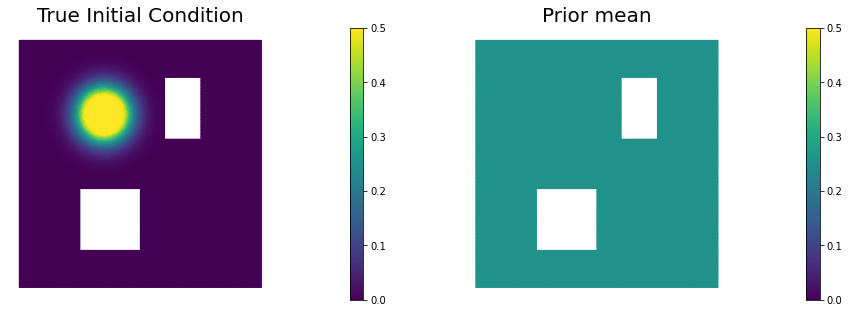

In [7]:
objs = [dl.Function(Vh,true_initial_condition),
        dl.Function(Vh,prior.mean)]
mytitles = ["True Initial Condition", "Prior mean"]
nb.multi1_plot(objs, mytitles)
plt.show()

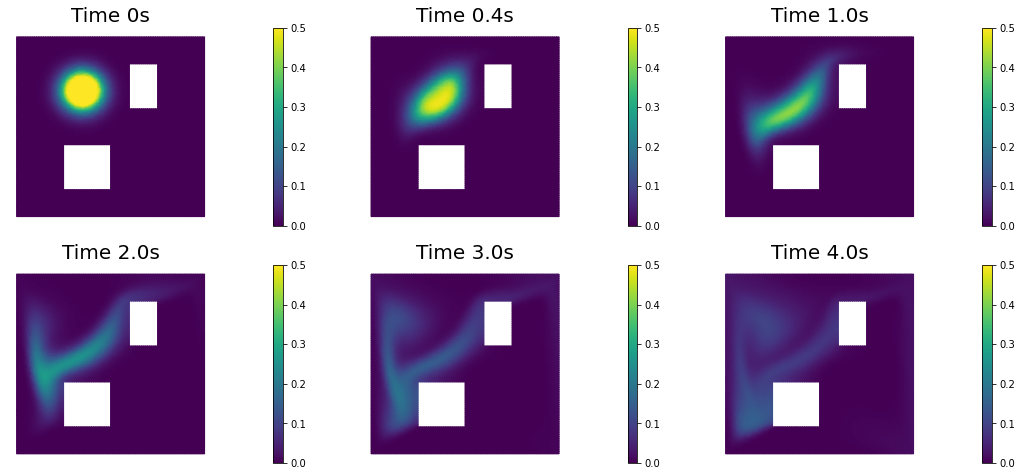

In [8]:
problem_true = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa_true, wind_velocity, True)
# relative noise level
rel_noise = 0.01

# initialize vector in the state space
utrue = problem_true.generate_vector(STATE)
x = [utrue, true_initial_condition, None]

# solve forward problem
before_solve = time.time()
problem_true.solveFwd(x[STATE], x)
after_solve = time.time()

# observe solution and add error
misfit.observe(x, misfit.d)
MAX = misfit.d.norm("linf", "linf")
noise_std_dev = rel_noise * MAX
parRandom.normal_perturb(noise_std_dev,misfit.d)

misfit.noise_variance = noise_std_dev*noise_std_dev

# plot solution
nb.show_solution(Vh, true_initial_condition, utrue, "Solution")
plt.savefig("forward_solution.pdf",pad_inches=1)

In [9]:
print("Time of one forward solve, {0} dofs and {1} timesteps: {2} seconds".format(dofs,nt,after_solve-before_solve))

Time of one forward solve, 8335 dofs and 40 timesteps: 0.05164790153503418 seconds


In [10]:
# def TimeFwdSolve(dofs,nt):
#     mesh = dl.refine( dl.Mesh("adv_diff_dofs_{0}.xml".format(dofs)) )
#     wind_velocity = computeVelocityField(mesh)
#     Vh = dl.FunctionSpace(mesh, "Lagrange", 1)
    
#     ic_expr = dl.Expression(
#         'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2) +  std::pow(x[1]-0.7,2))))',
#         element=Vh.ufl_element())
#     true_initial_condition = dl.interpolate(ic_expr, Vh).vector()
#     t_init         = 0.
#     t_final        = 4.
#     t_1            = 1.
#     dt             = t_final/nt #.1
#     observation_dt = .2
#     simulation_times = np.arange(t_init, t_final+.5*dt, dt)
#     observation_times = np.arange(t_1, t_final+.5*dt, observation_dt)
#     misfit = SpaceTimePointwiseStateObservation(Vh, observation_times, targets)
    
#     kappa_true = 0.001
#     gamma = 1.
#     delta = 8.
#     # initialize prior w/ covariance C = (delta * I + gamma * Laplacian)^{-2}
#     prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
#     # constant mean
#     prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    
#     problem_true = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa_true, wind_velocity, True)
#     rel_noise = 0.01
#     # initialize vector in the state space
#     utrue = problem_true.generate_vector(STATE)
#     x = [utrue, true_initial_condition, None]

#     # solve forward problem
#     before_solve = time.time()
#     problem_true.solveFwd(x[STATE], x)
#     after_solve = time.time()
    
#     return after_solve-before_solve

# dofs_range = [253, 605, 1225, 1879, 5443, 8335]
# nt_range = [20, 40, 80, 160]
# solve_times = np.zeros((len(dofs_range), len(nt_range)))
# for dd in range(len(dofs_range)):
#     for nn in range(len(nt_range)):
#         print("dofs, nt: ({0},{1})".format(dofs_range[dd],nt_range[nn]))
#         solve_times[dd,nn]= TimeFwdSolve(dofs_range[dd],nt_range[nn])

In [11]:
# print(solve_times)

In [12]:
# for i in range(solve_times.shape[1]):
#     plt.plot(dofs_range,solve_times[:,i], label=f'nt = {nt_range[i]}')

# plt.xlabel('dofs')
# plt.ylabel('time (seconds)')
# plt.title('Time of one forward solve')
# plt.legend()

In [13]:
# for i in range(solve_times.shape[0]):
#     plt.plot(nt_range,solve_times[i,:], label=f'dofs = {dofs_range[i]}')

# plt.xlabel('timesteps')
# plt.ylabel('time (seconds)')
# plt.title('Time of one forward solve')
# plt.legend(loc='upper left')

In [14]:
# def TimeLowRank(dofs):
#     nt = 160
#     mesh = dl.refine( dl.Mesh("adv_diff_dofs_{0}.xml".format(dofs)) )
#     wind_velocity = computeVelocityField(mesh)
#     Vh = dl.FunctionSpace(mesh, "Lagrange", 1)
    
#     ic_expr = dl.Expression(
#         'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2) +  std::pow(x[1]-0.7,2))))',
#         element=Vh.ufl_element())
#     true_initial_condition = dl.interpolate(ic_expr, Vh).vector()
#     t_init         = 0.
#     t_final        = 4.
#     t_1            = 1.
#     dt             = t_final/nt #.1
#     observation_dt = .2
#     simulation_times = np.arange(t_init, t_final+.5*dt, dt)
#     observation_times = np.arange(t_1, t_final+.5*dt, observation_dt)
#     misfit = SpaceTimePointwiseStateObservation(Vh, observation_times, targets)
    
#     kappa_true = 0.001
#     gamma = 1.
#     delta = 8.
#     # initialize prior w/ covariance C = (delta * I + gamma * Laplacian)^{-2}
#     prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
#     # constant mean
#     prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    
#     problem_true = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa_true, wind_velocity, True)
#     rel_noise = 0.01
#     # initialize vector in the state space
#     utrue = problem_true.generate_vector(STATE)
#     x = [utrue, true_initial_condition, None]

#     # solve forward problem
#     problem_true.solveFwd(x[STATE], x)
    
#     misfit.observe(x, misfit.d)
#     MAX = misfit.d.norm("linf", "linf")
#     noise_std_dev = rel_noise * MAX
#     parRandom.normal_perturb(noise_std_dev,misfit.d)
#     misfit.noise_variance = noise_std_dev*noise_std_dev
    
#     before_lowrank = time.time()
#     H_misfit_only = ReducedHessian(problem_true, misfit_only=True)
#     k = 200
#     pad = 40
#     Omega = MultiVector(x[PARAMETER], k+pad)
#     parRandom.normal(1., Omega)
#     lmbda, V = singlePass(H_misfit_only, Omega, k)
#     after_lowrank = time.time()
    
#     return after_lowrank-before_lowrank

# dofs_range = [605, 1225, 1879, 5443, 8335]
# lowrank_times = np.zeros(len(dofs_range))
# for dd in range(len(dofs_range)):
#     print("dofs: {0}".format(dofs_range[dd]))
#     lowrank_times[dd] = TimeLowRank(dofs_range[dd])

In [15]:
# plt.plot(dofs_range,lowrank_times)
# plt.xlabel('dofs')
# plt.ylabel('time (seconds)')
# plt.title('Time of computing low rank Hessian')

In [16]:
# def EigenvalsFromDof(dofs):
#     nt = 160
#     mesh = dl.refine( dl.Mesh("adv_diff_dofs_{0}.xml".format(dofs)) )
#     wind_velocity = computeVelocityField(mesh)
#     Vh = dl.FunctionSpace(mesh, "Lagrange", 1)
    
#     ic_expr = dl.Expression(
#         'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2) +  std::pow(x[1]-0.7,2))))',
#         element=Vh.ufl_element())
#     true_initial_condition = dl.interpolate(ic_expr, Vh).vector()
#     t_init         = 0.
#     t_final        = 4.
#     t_1            = 1.
#     dt             = t_final/nt #.1
#     observation_dt = .2
#     simulation_times = np.arange(t_init, t_final+.5*dt, dt)
#     observation_times = np.arange(t_1, t_final+.5*dt, observation_dt)
#     misfit = SpaceTimePointwiseStateObservation(Vh, observation_times, targets)
    
#     kappa_true = 0.001
#     gamma = 1.
#     delta = 8.
#     # initialize prior w/ covariance C = (delta * I + gamma * Laplacian)^{-2}
#     prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
#     # constant mean
#     prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    
#     problem_true = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa_true, wind_velocity, True)
#     rel_noise = 0.01
#     # initialize vector in the state space
#     utrue = problem_true.generate_vector(STATE)
#     x = [utrue, true_initial_condition, None]

#     # solve forward problem
#     problem_true.solveFwd(x[STATE], x)
    
#     misfit.observe(x, misfit.d)
#     MAX = misfit.d.norm("linf", "linf")
#     noise_std_dev = rel_noise * MAX
#     parRandom.normal_perturb(noise_std_dev,misfit.d)
#     misfit.noise_variance = noise_std_dev*noise_std_dev
    
#     H_misfit_only = ReducedHessian(problem_true, misfit_only=True)
#     k = 200
#     pad = 40
#     Omega = MultiVector(x[PARAMETER], k+pad)
#     parRandom.normal(1., Omega)
#     lmbda, V = singlePass(H_misfit_only, Omega, k)
    
#     return lmbda

# dofs_range = [605, 1225, 1879, 5443, 8335]
# lmbdas = [0]*len(dofs_range)
# for dd in range(len(dofs_range)):
#     print("dofs: {0}".format(dofs_range[dd]))
#     lmbda = EigenvalsFromDof(dofs_range[dd])
#     lmbdas[dd] = lmbda

In [17]:
# for dd in range(len(dofs_range)):
#     plt.semilogy(range(lmbdas[dd].shape[0]), lmbdas[dd],label='dof = {0}'.format(dofs_range[dd]))
# plt.ylabel('eigenvalue')
# plt.legend()

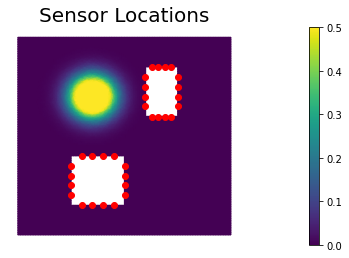

In [18]:
# plot target locations
nb.plot(dl.Function(Vh,true_initial_condition),mytitle='Sensor Locations')
plt.scatter(targets[:,0],targets[:,1],color='red')

In [19]:
# Compare spectra of preconditioned vs unpreconditioned Hessian

# H = ReducedHessian(problem_true, misfit_only=True)
# k = 200
# p = 40
# Omega = MultiVector(x[PARAMETER], k+p)
# parRandom.normal(1., Omega)
# lmbda0, V0 = singlePassG(H, prior.R, prior.Rsolver, Omega, k)
# lmbda1, V1 = singlePass(H, Omega, k)

# plt.figure(figsize=(8,8))
# plt.rcParams.update({'font.size': 16})
# plt.semilogy(lmbda0,label='prior preconditioned')
# plt.semilogy(lmbda1,label='unpreconditioned')
# plt.ylabel('eigenvalue')
# plt.legend()

In [20]:
def ComputePosterior(mesh, Vh, gamma, delta, misfit, simulation_times, kappa, wind_velocity):
    prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
    prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    
    problem = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa, wind_velocity, True)
    
    ## Compute the gradient
    [u,m,p] = problem.generate_vector()
    # forward solve
    problem.solveFwd(u, [u,m,p])
    # adjoint solve
    problem.solveAdj(p, [u,m,p])
    # initialize a vector in the parameter space
    mg = problem.generate_vector(PARAMETER)
    # evaluate gradient and store in mg
    grad_norm = problem.evalGradientParameter([u,m,p], mg)
    
    ## Compute posterior precision
    # matrix free application of posterior precision/covariance
    H = ReducedHessian(problem, misfit_only=True)
    
    # finds eigenvalues/vectors of H*x = lambda*R*x
    #k = 120
    k = 200
    p = 40
    Omega = MultiVector(x[PARAMETER], k+p)
    parRandom.normal(1., Omega)
    lmbda, V = singlePassG(H, prior.R, prior.Rsolver, Omega, k)

    posterior = GaussianLRPosterior(prior, lmbda, V, True)
    
    ## Compute posterior mean
    H.misfit_only = False
    solver = CGSolverSteihaug()
    solver.set_operator(H)
    solver.set_preconditioner( posterior.Hlr )
    solver.parameters["print_level"] = -1
    solver.parameters["rel_tolerance"] = 1e-6
    solver.solve(m, -mg)
    problem.solveFwd(u, [u,m,p])
    posterior.mean = m
    
    return posterior,mg,lmbda,V

def ComputePosteriorUnprecon(lmbda, V, misfit, simulation_times, kappa, wind_velocity, gamma, delta):
    prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
    prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    
    problem = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa, wind_velocity, True)
    
    ## Compute the gradient
    [u,m,p] = problem.generate_vector()
    # forward solve
    problem.solveFwd(u, [u,m,p])
    # adjoint solve
    problem.solveAdj(p, [u,m,p]) # these last three lines don't use the prior and should be precomputed
    # initialize a vector in the parameter space
    mg = problem.generate_vector(PARAMETER)
    # evaluate gradient and store in mg
    grad_norm = problem.evalGradientParameter([u,m,p], mg) # this involves the prior so we should compute it here
    
    ## Compute posterior precision
    # matrix free application of posterior precision/covariance
    H = ReducedHessian(problem, misfit_only=True)  # shouldn't need to do this, just use lmbda, V and add the prior
    
    posterior = GaussianLRPosterior(prior, lmbda, V, False)

#     Compute posterior mean
    H.misfit_only = False
    solver = CGSolverSteihaug()
    solver.set_operator(H) # use lmbda, V plus the prior here
    solver.set_preconditioner( posterior.Hlr )
    solver.parameters["print_level"] = -1
    solver.parameters["rel_tolerance"] = 1e-6
    solver.solve(m, -mg)
    problem.solveFwd(u, [u,m,p])
    posterior.mean = m
    
#     H = posterior.Hlr
#     H.solve(m,-mg)
#     posterior.mean = m

#     nb.plot(dl.Function(Vh,m))
    
    return posterior,mg

In [21]:
# prior precision of kappa -- normal centered at -2, stdev = 3 (log values)
q_kappa = 1/3
# prior mean of kappa
mu_kappa = -2

# # prior precision and mean of gamma and delta
# q_g = 1/2
# q_d = 1/2
# mu_g = 5
# mu_d = 5

# hyperprior parameters
alpha_del = 1
alpha_gam = 1
beta_del = 1e-4
beta_gam = 1e-4

In [22]:
# -log pi(kappa | u_d) (- log posterior marginal pdf of kappa)
def neglogpi_kappa(kappa):
    # compute new posterior
    gamma = 1.
    delta = 8.
    posterior,mg,lmbda,V = ComputePosterior(mesh, Vh, gamma, delta, misfit, simulation_times, kappa, wind_velocity)
    # -log(|Q_u_0|/|Q_u_0^\ast|)
    det_ratio = 0.0
    for ll in posterior.d:
        det_ratio += np.log(1+ll)
    # -log pdf of kappa prior
    kappa_prior = 0.5*(q_kappa**2)*(np.log10(kappa)-mu_kappa)**2
    # u_0^\ast^T Q_u_0^\ast u_0^\ast
    #uQu = - 0.5*posterior.Hlr.inner(posterior.mean,posterior.mean) # does unnecessary work + introduces error
    uQu = 0.5*mg.inner(posterior.mean)
    return det_ratio + kappa_prior + uQu

# -log pi(gamma, delta | u_d) (- log posterior marginal joint pdf of gamma, delta)
def neglogpi_gamma_delta(lmbda, V, kappa, gamma, delta):
    # compute new posterior
    #posterior,mg,lmbda,V = ComputePosterior(mesh, Vh, gamma, delta, misfit, simulation_times, kappa, wind_velocity)
    posterior,mg = ComputePosteriorUnprecon(lmbda, V, misfit, simulation_times, kappa, wind_velocity, gamma, delta)
    # -log(|Q_u_0|/|Q_u_0^\ast|)
    # Bhelp = Q_u0^-1 * V
    Bhelp = MultiVector(V)
    for i in range(V.nvec()):
        posterior.prior.Rsolver.solve(Bhelp[i],V[i])
    # B = diag(lmbda) * V^T Q_u0^-1 V + I
    B = V.dot_mv(Bhelp)
    for i in range(B.shape[0]):
        B[i,:] *= lmbda[i]
        B[i,i] += 1.
    Bvals = np.linalg.eigvals(B)
    # det_ratio = np.sum(np.log(Bvals))
    det_ratio = np.sum(np.log(Bvals)) - (alpha_del-1)*np.log(delta) - (alpha_gam-1)*np.log(gamma)
    # -log pdf of gamma, delta prior
    # gamma_delta_prior = 0.5*(q_g**2)*(gamma-mu_g)**2 + 0.5*(q_d**2)*(delta-mu_d)**2
    gamma_delta_prior = beta_del*delta + beta_gam*gamma
    kappa_prior = 0.5*(q_kappa**2)*(np.log10(kappa)-mu_kappa)**2
    # u_0^\ast^T Q_u_0^\ast u_0^\ast
    #uQu = - 0.5*posterior.Hlr.inner(posterior.mean,posterior.mean) # does unnecessary work + introduces error
    uQu = 0.5*mg.inner(posterior.mean)
    # - mu_0 Q_u0 mu_0
    Qmu = dl.Vector(posterior.prior.R.mpi_comm())
    posterior.prior.init_vector(Qmu,0)
    posterior.prior.R.mult(posterior.prior.mean,Qmu)
    muQmu = 0.5*posterior.prior.mean.inner(Qmu)
    return det_ratio + gamma_delta_prior + kappa_prior + uQu + muQmu, det_ratio, gamma_delta_prior+kappa_prior, uQu, muQmu

In [23]:
# # posterior1,mg1 = ComputePosteriorUnprecon(lmbda, V, misfit, simulation_times, kappa, wind_velocity, 30, 1000)
# g1, d1  = 300, 100000
# posterior1 ,mg1 ,lmbda1 ,V1 = ComputePosterior(mesh, Vh, g1, d1, misfit, simulation_times, kappa_true, wind_velocity)
# posterior1_var,pr1,corr1 = posterior1.pointwise_variance(method="Exact")
# nb.plot(dl.Function(Vh,posterior1.mean),mytitle='Posterior mean, gam = {0}, del = {1}'.format(g1,d1))

In [24]:
# # posterior2,mg2 = ComputePosteriorUnprecon(lmbda, V, misfit, simulation_times, kappa, wind_velocity, 60, 2000)
# g2, d2 = 600,200000
# posterior2 ,mg2 ,lmbda2 ,V2 = ComputePosterior(mesh, Vh, g2, d2, misfit, simulation_times, kappa_true, wind_velocity)
# posterior2_var,pr2,corr2 = posterior2.pointwise_variance(method="Exact")
# nb.plot(dl.Function(Vh,posterior2.mean),mytitle='Posterior mean, gam = {0}, del = {1}'.format(g2,d2))

In [25]:
# nb.plot(dl.Function(Vh,posterior1_var),mytitle='Posterior var, gam = {0}, del = {1}'.format(g1,d1))

In [26]:
# nb.plot(dl.Function(Vh,posterior2_var),mytitle='Posterior var, gamma = {0}, delta = {1}'.format(g2,d2))

In [27]:
# nb.plot(dl.Function(Vh,pr1),mytitle='Prior var, gam = {0}, del = {1}'.format(g1,d1))

In [28]:
# nb.plot(dl.Function(Vh,pr2),mytitle='Prior var, gam = {0}, del = {1}'.format(g2,d2))

In [29]:
dummy_prior = BiLaplacianPrior(Vh, 1., 8., robin_bc=True)
dummy_prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
kappa = 0.001
problem = TimeDependentAD(mesh, [Vh,Vh,Vh], dummy_prior, misfit, simulation_times, kappa, wind_velocity, True)
H_misfit_only = ReducedHessian(problem, misfit_only=True)
k = 128
pad = 20
Omega = MultiVector(x[PARAMETER], k+pad)
parRandom.normal(1., Omega)
lmbda, V = singlePass(H_misfit_only, Omega, k)
Bhelp = MultiVector(V)

print(lmbda)

[6.14708598e+04 5.80028224e+04 5.24439949e+04 4.74841596e+04
 2.81864955e+04 2.58506961e+04 2.34325063e+04 2.27533036e+04
 1.53223316e+04 1.21346433e+04 1.15140825e+04 8.53506043e+03
 7.17739682e+03 6.25054072e+03 6.04505311e+03 5.26259885e+03
 4.21660673e+03 4.03660896e+03 3.58357932e+03 2.80067076e+03
 2.42032486e+03 1.75407200e+03 1.49241729e+03 1.44871504e+03
 1.19228812e+03 1.15937170e+03 1.07768403e+03 9.16123535e+02
 8.44781752e+02 7.03593785e+02 6.83026562e+02 4.91086748e+02
 4.15904528e+02 3.62462842e+02 3.19342941e+02 2.79228946e+02
 2.36461605e+02 2.03765066e+02 1.97247023e+02 1.84678815e+02
 1.76990778e+02 1.72636480e+02 1.42260714e+02 1.25780737e+02
 1.03714785e+02 8.82409937e+01 8.28570081e+01 7.87286442e+01
 6.62162884e+01 5.95846594e+01 5.36304936e+01 5.28902912e+01
 4.52083056e+01 4.33754860e+01 3.79400376e+01 3.10579139e+01
 2.81296374e+01 2.27817537e+01 2.17453883e+01 1.97835561e+01
 1.88328890e+01 1.43216105e+01 1.23541825e+01 1.05349203e+01
 9.10823334e+00 8.664122

In [30]:
# ## Compute the gradient
# [u,m,p] = problem.generate_vector()
# # forward solve
# %lprun -f TimeDependentAD.solveFwd problem.solveFwd(u, [u,m,p])
# # adjoint solve
# problem.solveAdj(p, [u,m,p])
    
# %lprun -f LowRankHessianUnprecon.__init__ posterior = GaussianLRPosterior(dummy_prior, lmbda, V, False)
# %lprun -f ComputePosteriorUnprecon logpi_ijk,det_ijk,pri_ijk,uQu_ijk,muQmu_ijk = neglogpi_gamma_delta(lmbda, V, kappa, 0.5,6)
# %lprun -f _BilaplacianRsolver.solve dummy_prior.Rsolver.solve(Bhelp[0],V[0])

In [31]:
# plot -log pi for a range of gammas, deltas
# g_range = np.linspace(0.4,600,5) #was at 0.1-2 before switching to 1D problem
# d_range = np.linspace(20,200000,5) #was at 1-15 before switching to 1D problem
nn = 10
nk = 1
g_range = np.linspace(0.5,0.8,nn)
# g_range = np.linspace(0.3,0.8,nn)
d_range = np.linspace(2,7.5,nn)
# d_range = np.linspace(2,10,nn)
# k_range = np.linspace(0.0007, 0.001, nk)
k_range = np.linspace(0.001, 0.001, nk)
logpi = np.zeros((nn,nn,nk))
det_ratios = np.zeros((nn,nn,nk))
priors = np.zeros((nn,nn,nk))
uQus = np.zeros((nn,nn,nk))
muQmus = np.zeros((nn,nn,nk))
print('Progress in indices computed from (0,0,0) to ({0},{0},{1}):'.format(nn-1,nk-1))
for kk in range(nk):
    # compute unpreconditioned low rank decomposition
    precompute_start = time.time()
    
    dummy_prior = BiLaplacianPrior(Vh, 1., 8., robin_bc=True)
    dummy_prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    kappa = k_range[kk]
    problem = TimeDependentAD(mesh, [Vh,Vh,Vh], dummy_prior, misfit, simulation_times, kappa, wind_velocity, True)
    H_misfit_only = ReducedHessian(problem, misfit_only=True)
    k = 128 #200
    pad = 20 #40
    Omega = MultiVector(x[PARAMETER], k+pad)
    parRandom.normal(1., Omega)
    lmbda, V = singlePass(H_misfit_only, Omega, k)
#     [u,m,p] = problem.generate_vector()
#     problem.solveFwd(u, [u,m,p])
#     problem.solveAdj(p, [u,m,p])
    
    precompute_end = time.time()
    print(f"Precompute time: {precompute_end-precompute_start} seconds")
    for i in range(nn):
        for j in range(nn):
            logpi_ijk,det_ijk,pri_ijk,uQu_ijk,muQmu_ijk = neglogpi_gamma_delta(lmbda, V, kappa, g_range[i],d_range[j])
            logpi[i,j,kk] = logpi_ijk
            det_ratios[i,j,kk] = det_ijk
            priors[i,j,kk] = pri_ijk
            uQus[i,j,kk] = uQu_ijk
            muQmus[i,j,kk] = muQmu_ijk
            print('({0},{1},{2})'.format(i,j,kk))
    compute_end = time.time()
    print(f"Compute time: {compute_end-precompute_end} seconds")

Progress in indices computed from (0,0,0) to (9,9,0):
Precompute time: 9.950878143310547 seconds
(0,0,0)
(0,1,0)
(0,2,0)
(0,3,0)
(0,4,0)
(0,5,0)
(0,6,0)
(0,7,0)
(0,8,0)
(0,9,0)
(1,0,0)
(1,1,0)
(1,2,0)
(1,3,0)
(1,4,0)
(1,5,0)
(1,6,0)
(1,7,0)
(1,8,0)
(1,9,0)
(2,0,0)
(2,1,0)
(2,2,0)
(2,3,0)
(2,4,0)
(2,5,0)
(2,6,0)
(2,7,0)
(2,8,0)
(2,9,0)
(3,0,0)
(3,1,0)
(3,2,0)
(3,3,0)
(3,4,0)
(3,5,0)
(3,6,0)
(3,7,0)
(3,8,0)
(3,9,0)
(4,0,0)
(4,1,0)
(4,2,0)
(4,3,0)
(4,4,0)
(4,5,0)
(4,6,0)
(4,7,0)
(4,8,0)
(4,9,0)
(5,0,0)
(5,1,0)
(5,2,0)
(5,3,0)
(5,4,0)
(5,5,0)
(5,6,0)
(5,7,0)
(5,8,0)
(5,9,0)
(6,0,0)
(6,1,0)
(6,2,0)
(6,3,0)
(6,4,0)
(6,5,0)
(6,6,0)
(6,7,0)
(6,8,0)
(6,9,0)
(7,0,0)
(7,1,0)
(7,2,0)
(7,3,0)
(7,4,0)
(7,5,0)
(7,6,0)
(7,7,0)
(7,8,0)
(7,9,0)
(8,0,0)
(8,1,0)
(8,2,0)
(8,3,0)
(8,4,0)
(8,5,0)
(8,6,0)
(8,7,0)
(8,8,0)
(8,9,0)
(9,0,0)
(9,1,0)
(9,2,0)
(9,3,0)
(9,4,0)
(9,5,0)
(9,6,0)
(9,7,0)
(9,8,0)
(9,9,0)
Compute time: 156.18367457389832 seconds


Text(0.5, 0, '$\\delta$')

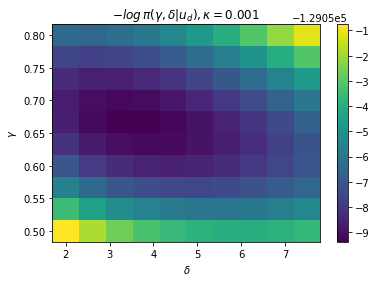

In [32]:
kk = 0
plt.pcolormesh(d_range,g_range,logpi[:,:,kk])
plt.colorbar()
plt.title(r'$-log \, \pi(\gamma, \delta | u_d),\kappa={0}$'.format(k_range[kk]))
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

Text(0.5, 0, '$\\delta$')

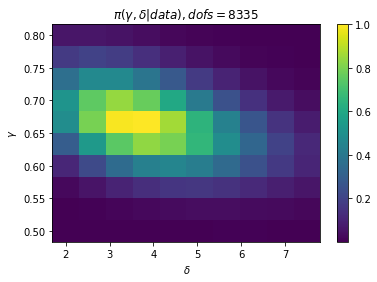

In [33]:
# scaled arbitrarily to have max value 1 in order to avoid overflow errors
kk = 0
plt.pcolormesh(d_range,g_range,np.exp(-logpi[:,:,kk]+np.min(logpi)))
plt.colorbar()
# plt.title(r'$\pi(\gamma, \delta | data),\kappa={0}$'.format(k_range[kk]))
plt.title(r'$\pi(\gamma, \delta | data), dofs={0}$'.format(dofs))
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

In [34]:
# # scaled arbitrarily to have max value 1 in order to avoid overflow errors
# kk = 1
# plt.pcolormesh(d_range,g_range,np.exp(-logpi[:,:,kk]+np.min(logpi)))
# plt.colorbar()
# plt.title(r'$\pi(\gamma, \delta | data),\kappa={0}$'.format(k_range[kk]))
# plt.ylabel(r'$\gamma$')
# plt.xlabel(r'$\delta$')

In [35]:
# plt.plot([605, 1225, 1879, 5443, 8335], [30.76, 46.5, 64.45, 151.45, 242.08], marker='.')
# plt.xlabel('dofs')
# plt.ylabel('time (s)')
# plt.title('Runtime of pi(gamma, delta) calculation')
# for 40 timesteps, 100 (gamma, delta) pairs, kappa = 0.001, not including precomputation time